In [17]:
!pip install -q torch==2.12.0 --index-url https://download.pytorch.org/whl/cu126

In [18]:
import sys, torch
import torch.nn as nn

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# Тест: создаём оптимизатор
model = nn.Sequential(nn.Linear(10, 5), nn.ReLU(), nn.Linear(5, 1))
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.BCELoss()

print("✅ Optimizer создан — можно работать")

Python: 3.13.15
PyTorch: 2.12.0+cu126
GPU: True
Device: Tesla T4
✅ Optimizer создан — можно работать


In [19]:
!pip install -q datasets pandas matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

dataset = load_dataset("lacg030175/CIC-IoT-2023-neto-subsample", "random_3way", split="train[:10000]")
df = dataset.to_pandas()

print(f"Датасет успешно загружен. Размер: {df.shape}")
print("\nПервые 5 строк:")
display(df.head())

Датасет успешно загружен. Размер: (10000, 50)

Первые 5 строк:


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Number,Magnitue,Radius,Covariance,Variance,Weight,Label,Label_orig,attack_class,label
0,0.000000,741.859985,5.94,63.360001,185.031937,185.031937,0.0,0.0,0.0,0.0,...,9.5,43.611145,761.456787,305219.3125,0.95,141.550003,DDoS-ACK_Fragmentation,DDoS-ACK_Fragmentation,DDoS,1
1,5.319937,22640.099609,10.40,74.800003,41.719051,41.719051,0.0,0.0,0.0,0.0,...,13.5,34.210743,916.202209,420220.3750,1.00,244.600006,BenignTraffic,BenignTraffic,Benign,0
2,3.092224,272.600006,17.00,64.000000,0.491930,0.491930,0.0,0.0,0.0,0.0,...,5.5,13.711309,0.000000,0.0000,0.00,38.500000,DNS_Spoofing,DNS_Spoofing,Spoofing,1
3,8.375284,5683.399902,6.00,155.100006,35.487621,35.487621,0.0,0.0,0.0,0.0,...,13.5,30.803919,1167.457153,684978.8125,1.00,244.600006,MITM-ArpSpoofing,MITM-ArpSpoofing,Spoofing,1
4,0.088201,82134.500000,17.00,64.000000,610.776062,610.776062,0.0,0.0,0.0,0.0,...,9.5,41.680603,769.472107,311678.8125,0.95,141.550003,DDoS-UDP_Fragmentation,DDoS-UDP_Fragmentation,DDoS,1


КОЛИЧЕСТВО ТРАФИКА ПО КЛАССАМ
Attack (Атака): 8617 записей (86.2%)
Benign (Норма): 1383 записей (13.8%)
Всего записей: 10000


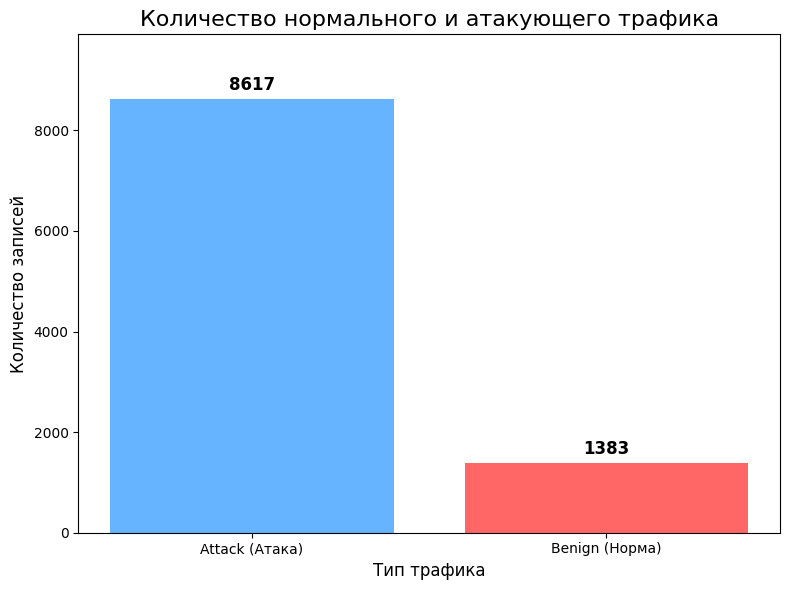

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

label_map = {0: 'Benign (Норма)', 1: 'Attack (Атака)'}
df['label_name'] = df['label'].map(label_map)

counts = df['label_name'].value_counts()
total = len(df)

print("=" * 50)
print("КОЛИЧЕСТВО ТРАФИКА ПО КЛАССАМ")
print("=" * 50)
for name, count in counts.items():
    percent = count / total * 100
    print(f"{name}: {count} записей ({percent:.1f}%)")
print(f"Всего записей: {total}")

plt.figure(figsize=(8, 6))
colors = ['#66b3ff', '#ff6666']
bars = plt.bar(counts.index, counts.values, color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + total*0.01,
             f'{int(height)}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Количество нормального и атакующего трафика', fontsize=16)
plt.xlabel('Тип трафика', fontsize=12)
plt.ylabel('Количество записей', fontsize=12)
plt.ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.savefig('traffic_count_bar.png', dpi=150)
plt.show()

МЕТРИКИ КЛАССИФИКАЦИИ
Accuracy : 0.9660
Precision: 0.9726
Recall   : 0.9884
F1-score : 0.9804
ROC-AUC  : 0.9895

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.83      0.87       277
           1       0.97      0.99      0.98      1723

    accuracy                           0.97      2000
   macro avg       0.95      0.91      0.93      2000
weighted avg       0.97      0.97      0.97      2000



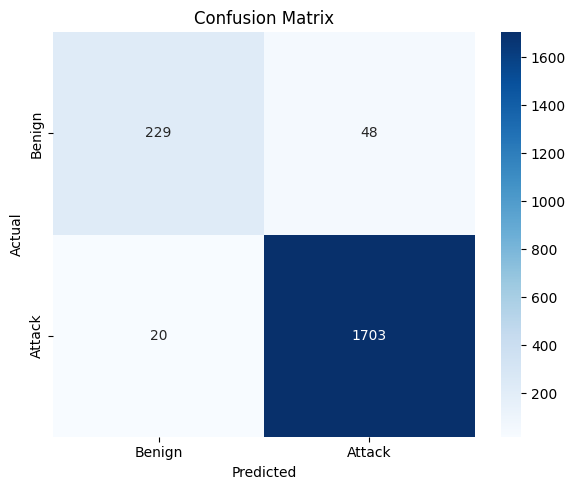

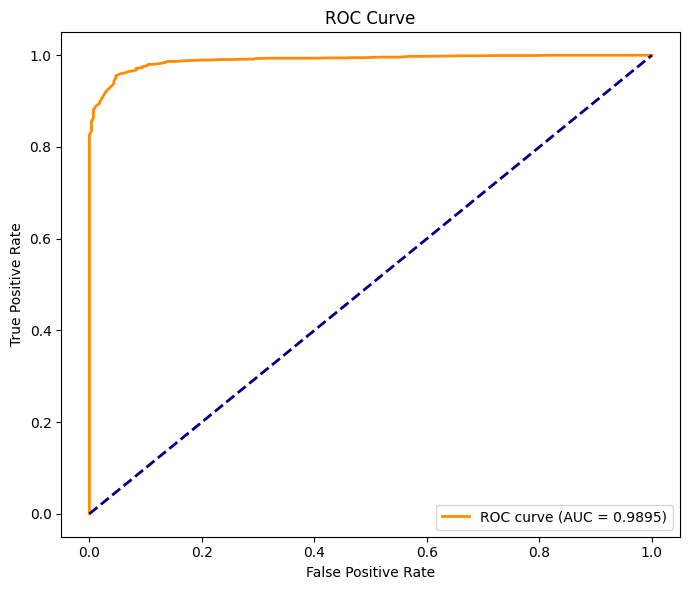

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])
X = numeric_df.drop(columns=['label'], errors='ignore').fillna(0)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # вероятность класса 1

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

print("=" * 50)
print("МЕТРИКИ КЛАССИФИКАЦИИ")
print("=" * 50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

Топ-5 признаков:
1. rst_count: 0.1403
2. IAT: 0.1355
3. urg_count: 0.1028
4. Header_Length: 0.0765
5. flow_duration: 0.0750


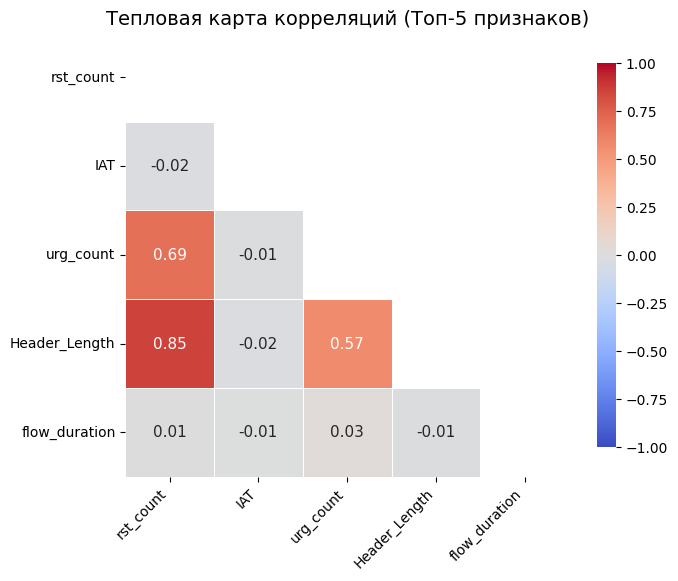

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=['label'], errors='ignore').select_dtypes(include=[np.number]).fillna(0)
y = df['label']

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
top_5 = importances.sort_values(ascending=False).head(5).index.tolist()

print("Топ-5 признаков:")
for i, feat in enumerate(top_5, 1):
    print(f"{i}. {feat}: {importances[feat]:.4f}")

plt.figure(figsize=(7, 6))
corr_top5 = df[top_5].corr()

mask = np.triu(np.ones_like(corr_top5, dtype=bool))

sns.heatmap(
    corr_top5,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 11}
)

plt.title('Тепловая карта корреляций (Топ-5 признаков)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('heatmap_top5.png', dpi=150)
plt.show()

=== MITRE ATT&CK Coverage ===
 attck_id                        attck_name  count
    T1498         Network Denial of Service   2819
    T1557           Adversary-in-the-Middle    674
    T1046         Network Service Discovery    370
    T1018           Remote System Discovery    331
    T1595                   Active Scanning    273
    T1185         Browser Session Hijacking     40
    T1059 Command and Scripting Interpreter     36
T1059.007                        JavaScript     27
    T1190 Exploit Public-Facing Application     13

Уникальных ATT&CK техник в датасете: 9


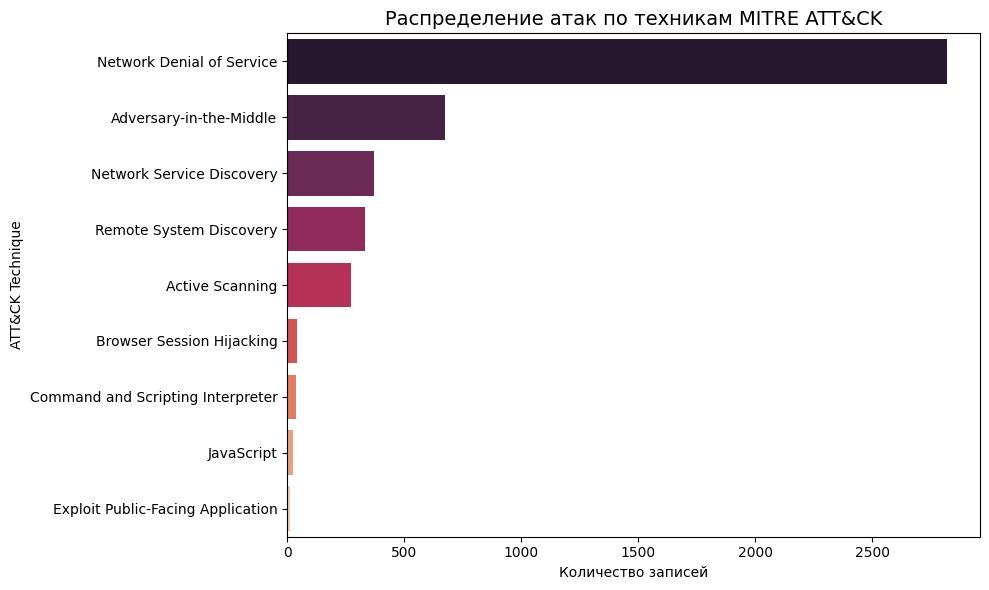

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ATTACK_MAPPING = {
    # DDoS
    "DDoS-ACK_Fragmentation":       ("T1498", "Network Denial of Service"),
    "DDoS-UDP_Fragmentation":       ("T1498", "Network Denial of Service"),
    "DDoS-SYN_Flood":               ("T1498", "Network Denial of Service"),
    "DDoS-TCP_Flood":               ("T1498", "Network Denial of Service"),
    "DDoS-HTTP_Flood":              ("T1498", "Network Denial of Service"),
    "DDoS-PSHACK_Fragmentation":    ("T1498", "Network Denial of Service"),
    "DDoS-ICMP_Flood":              ("T1498", "Network Denial of Service"),
    "DDoS-SlowLoris":               ("T1498", "Network Denial of Service"),
    # Spoofing
    "DNS_Spoofing":                 ("T1557", "Adversary-in-the-Middle"),
    "MITM-ArpSpoofing":             ("T1557", "Adversary-in-the-Middle"),
    # Brute force / Recon
    "Recon-PortScan":               ("T1046", "Network Service Discovery"),
    "VulnerabilityScan":            ("T1595", "Active Scanning"),
    "Recon-HostDiscovery":          ("T1018", "Remote System Discovery"),
    # Mirai / IoT malware
    "Mirai-greeth_flood":           ("T1498", "Network Denial of Service"),
    "Mirai-udpplain":               ("T1498", "Network Denial of Service"),
    # Web attacks
    "BrowserHijacking":             ("T1185", "Browser Session Hijacking"),
    "Uploading_Attack":             ("T1190", "Exploit Public-Facing Application"),
    "XSS":                          ("T1059.007", "JavaScript"),
    "SQL_injection":                ("T1190", "Exploit Public-Facing Application"),
    "CommandInjection":             ("T1059", "Command and Scripting Interpreter"),
    # Normal
    "BenignTraffic":                ("—", "Benign"),
}

df["attck_id"]     = df["Label_orig"].map(lambda x: ATTACK_MAPPING.get(x, ("—", "Unknown"))[0])
df["attck_name"]   = df["Label_orig"].map(lambda x: ATTACK_MAPPING.get(x, ("—", "Unknown"))[1])

attack_summary = (
    df[df["attck_id"] != "—"]
    .groupby(["attck_id", "attck_name"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("=== MITRE ATT&CK Coverage ===")
print(attack_summary.to_string(index=False))

unique_techniques = attack_summary["attck_id"].nunique()
print(f"\nУникальных ATT&CK техник в датасете: {unique_techniques}")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=attack_summary,
    y="attck_name",
    x="count",
    hue="attck_id",
    palette="rocket",
    legend=False
)
plt.title("Распределение атак по техникам MITRE ATT&CK", fontsize=14)
plt.xlabel("Количество записей")
plt.ylabel("ATT&CK Technique")
plt.tight_layout()
plt.savefig("attck_coverage.png", dpi=150)
plt.show()

attack_summary.to_csv("attck_coverage.csv", index=False)

In [24]:
from sklearn.preprocessing import StandardScaler
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Устройство:", device)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

X_train_t = torch.tensor(X_train_s, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_s.values, dtype=torch.float32).unsqueeze(1).to(device)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test_s.values,  dtype=torch.float32).unsqueeze(1).to(device)

print("Train:", X_train_t.shape, "| Test:", X_test_t.shape)

Устройство: cuda
Train: torch.Size([8000, 46]) | Test: torch.Size([2000, 46])


Epoch  0 | Loss: 0.7345
Epoch  5 | Loss: 0.6371
Epoch 10 | Loss: 0.5524
Epoch 15 | Loss: 0.4716

=== MLP ===
Accuracy : 0.8615
F1-score : 0.9256
ROC-AUC  : 0.8542


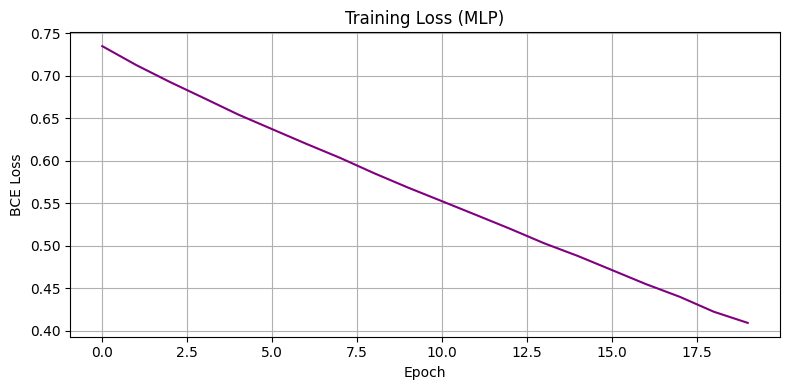

In [25]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1),          nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

mlp = MLP(X_train_t.shape[1]).to(device)
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)
criterion = nn.BCELoss()

losses = []
for epoch in range(20):
    mlp.train()
    optimizer.zero_grad()
    out = mlp(X_train_t)
    loss = criterion(out, y_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 5 == 0:
        print(f"Epoch {epoch:2d} | Loss: {loss.item():.4f}")

mlp.eval()
with torch.no_grad():
    y_proba_mlp = mlp(X_test_t).cpu().numpy().ravel()
y_pred_mlp = (y_proba_mlp > 0.5).astype(int)

acc_mlp = accuracy_score(y_test_s, y_pred_mlp)
f1_mlp  = f1_score(y_test_s, y_pred_mlp)
auc_mlp = roc_auc_score(y_test_s, y_proba_mlp)

print("\n=== MLP ===")
print(f"Accuracy : {acc_mlp:.4f}")
print(f"F1-score : {f1_mlp:.4f}")
print(f"ROC-AUC  : {auc_mlp:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(losses, color='purple')
plt.title('Training Loss (MLP)'); plt.xlabel('Epoch'); plt.ylabel('BCE Loss')
plt.grid(True); plt.tight_layout()
plt.savefig('mlp_training_loss.png', dpi=150)
plt.show()

Benign samples for training: 1383
Epoch   0 | Loss: 1.334304
Epoch  20 | Loss: 1.261981
Epoch  40 | Loss: 1.159755
Epoch  60 | Loss: 0.883791
Epoch  80 | Loss: 0.640144

Порог: 0.987825

=== Autoencoder ===
Accuracy : 0.2065
F1-score : 0.1590


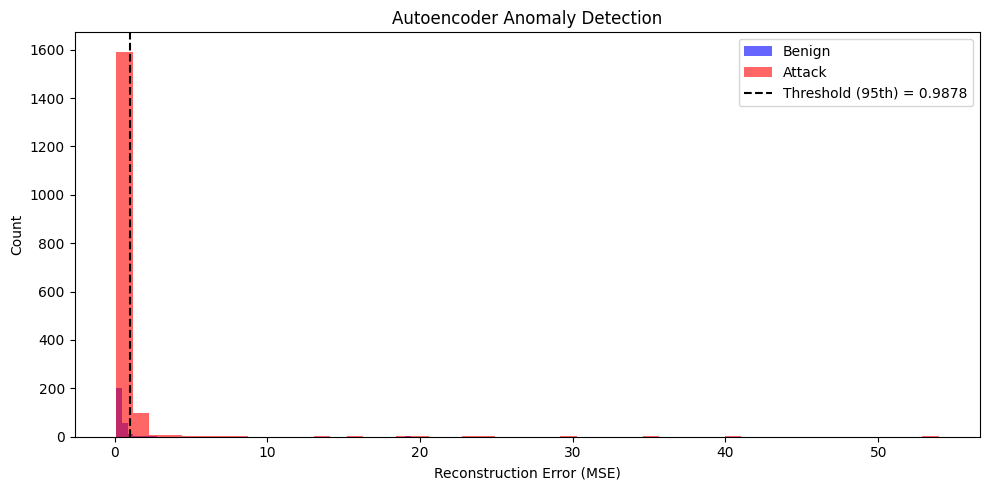

In [31]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16),        nn.ReLU(),
            nn.Linear(16, 8)
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),         nn.ReLU(),
            nn.Linear(16, 32),        nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

# Обучаем ТОЛЬКО на нормальном трафике
X_benign = X_scaled[y.values == 0]
X_benign_t = torch.tensor(X_benign, dtype=torch.float32).to(device)
print(f"Benign samples for training: {X_benign_t.shape[0]}")

ae = Autoencoder(X_train_t.shape[1]).to(device)
opt = torch.optim.Adam(ae.parameters(), lr=1e-3)
crit = nn.MSELoss()

ae_losses = []
for epoch in range(100):   # было 50
    ae.train()
    opt.zero_grad()
    out = ae(X_benign_t)
    loss = crit(out, X_benign_t)
    loss.backward()
    opt.step()
    ae_losses.append(loss.item())
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.6f}")

ae.eval()
with torch.no_grad():
    recon = ae(X_test_t)
    errors = ((recon - X_test_t) ** 2).mean(dim=1).cpu().numpy()

# === КЛЮЧЕВОЕ ИСПРАВЛЕНИЕ ===
# Порог по 95-му перцентилю benign-ошибок (а не mean+2std)
benign_errors = errors[y_test_s.values == 0]
threshold = np.percentile(benign_errors, 95)

y_pred_ae = (errors > threshold).astype(int)

acc_ae = accuracy_score(y_test_s, y_pred_ae)
f1_ae  = f1_score(y_test_s, y_pred_ae)

print(f"\nПорог: {threshold:.6f}")
print("\n=== Autoencoder ===")
print(f"Accuracy : {acc_ae:.4f}")
print(f"F1-score : {f1_ae:.4f}")

plt.figure(figsize=(10, 5))
plt.hist(errors[y_test_s.values == 0], bins=50, alpha=0.6, label='Benign', color='blue')
plt.hist(errors[y_test_s.values == 1], bins=50, alpha=0.6, label='Attack', color='red')
plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold (95th) = {threshold:.4f}')
plt.xlabel('Reconstruction Error (MSE)'); plt.ylabel('Count')
plt.title('Autoencoder Anomaly Detection')
plt.legend(); plt.tight_layout()
plt.savefig('autoencoder_anomaly.png', dpi=150)
plt.show()

In [32]:
comparison = pd.DataFrame({
    "Model": ["Random Forest (ML)", "MLP (DL)", "Autoencoder (DL, unsup.)"],
    "Accuracy": [accuracy, acc_mlp, acc_ae], # было acc_rf
    "F1-score": [f1, f1_mlp, f1_ae],         # было f1_rf
    "ROC-AUC":  [roc_auc, auc_mlp, None]      # было auc_rf
})
print(comparison.to_string(index=False))
comparison.to_csv('model_comparison.csv', index=False)

                   Model  Accuracy  F1-score  ROC-AUC
      Random Forest (ML)    0.9660  0.980426 0.989521
                MLP (DL)    0.8615  0.925598 0.854236
Autoencoder (DL, unsup.)    0.2065  0.158983      NaN


 attck_id                        attck_name  count
    T1498         Network Denial of Service   2819
    T1557           Adversary-in-the-Middle    674
    T1046         Network Service Discovery    370
    T1018           Remote System Discovery    331
    T1595                   Active Scanning    273
    T1185         Browser Session Hijacking     40
    T1059 Command and Scripting Interpreter     36
T1059.007                        JavaScript     27
    T1190 Exploit Public-Facing Application     13

Уникальных техник: 9


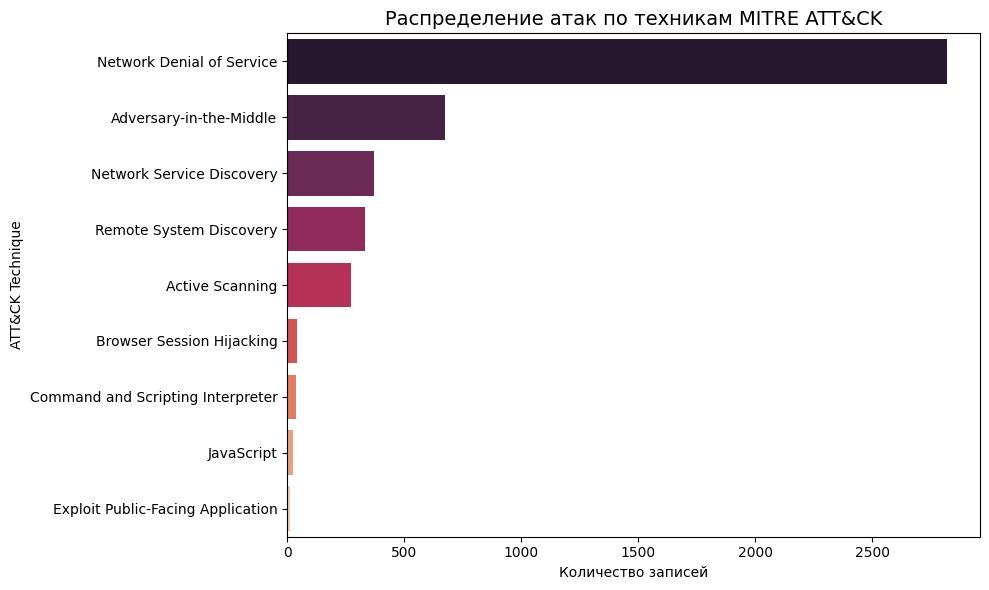

In [29]:
ATTACK_MAPPING = {
    "DDoS-ACK_Fragmentation":    ("T1498", "Network Denial of Service"),
    "DDoS-UDP_Fragmentation":    ("T1498", "Network Denial of Service"),
    "DDoS-SYN_Flood":            ("T1498", "Network Denial of Service"),
    "DDoS-TCP_Flood":            ("T1498", "Network Denial of Service"),
    "DDoS-HTTP_Flood":           ("T1498", "Network Denial of Service"),
    "DDoS-PSHACK_Fragmentation": ("T1498", "Network Denial of Service"),
    "DDoS-ICMP_Flood":           ("T1498", "Network Denial of Service"),
    "DDoS-SlowLoris":            ("T1498", "Network Denial of Service"),
    "DNS_Spoofing":              ("T1557", "Adversary-in-the-Middle"),
    "MITM-ArpSpoofing":          ("T1557", "Adversary-in-the-Middle"),
    "Recon-PortScan":            ("T1046", "Network Service Discovery"),
    "VulnerabilityScan":         ("T1595", "Active Scanning"),
    "Recon-HostDiscovery":       ("T1018", "Remote System Discovery"),
    "Mirai-greeth_flood":        ("T1498", "Network Denial of Service"),
    "Mirai-udpplain":            ("T1498", "Network Denial of Service"),
    "BrowserHijacking":          ("T1185", "Browser Session Hijacking"),
    "Uploading_Attack":          ("T1190", "Exploit Public-Facing Application"),
    "XSS":                       ("T1059.007", "JavaScript"),
    "SQL_injection":             ("T1190", "Exploit Public-Facing Application"),
    "CommandInjection":          ("T1059", "Command and Scripting Interpreter"),
    "BenignTraffic":             ("—", "Benign"),
}

df["attck_id"]   = df["Label_orig"].map(lambda x: ATTACK_MAPPING.get(x, ("—", "Unknown"))[0])
df["attck_name"] = df["Label_orig"].map(lambda x: ATTACK_MAPPING.get(x, ("—", "Unknown"))[1])

attack_summary = (
    df[df["attck_id"] != "—"]
    .groupby(["attck_id", "attck_name"])
    .size().reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(attack_summary.to_string(index=False))
print(f"\nУникальных техник: {attack_summary['attck_id'].nunique()}")

plt.figure(figsize=(10, 6))
sns.barplot(data=attack_summary, y="attck_name", x="count",
            hue="attck_id", palette="rocket", legend=False)
plt.title("Распределение атак по техникам MITRE ATT&CK", fontsize=14)
plt.xlabel("Количество записей"); plt.ylabel("ATT&CK Technique")
plt.tight_layout()
plt.savefig("attck_coverage.png", dpi=150)
plt.show()

attack_summary.to_csv("attck_coverage.csv", index=False)

In [30]:
import yaml

top_3 = top_5[:3]
thresholds = {feat: float(df[df["label"] == 0][feat].quantile(0.95)) for feat in top_3}

sigma_rule = {
    "title": "IoT Anomalous Traffic — Top Features Threshold",
    "id": "a1b2c3d4-0001-0002-0003-000000000001",
    "status": "experimental",
    "description": "Detects anomalous IoT traffic based on top ML-selected features. Generated by Local AI Threat Hunting Agent.",
    "references": [
        "https://attack.mitre.org/techniques/T1498/",
        "https://attack.mitre.org/techniques/T1557/"
    ],
    "author": "Your Name",
    "date": "2026/10/04",
    "tags": ["attack.impact", "attack.t1498", "attack.credential_access", "attack.t1557"],
    "logsource": {"product": "iot", "category": "network_flow"},
    "detection": {
        "selection": {feat: f">{thresholds[feat]:.2f}" for feat in top_3},
        "condition": "selection"
    },
    "falsepositives": ["Legitimate IoT firmware updates", "Bulk backup traffic"],
    "level": "high"
}

with open("sigma_rule_iot.yml", "w") as f:
    yaml.dump(sigma_rule, f, sort_keys=False, default_flow_style=False)

print(yaml.dump(sigma_rule, sort_keys=False, default_flow_style=False))

title: "IoT Anomalous Traffic \u2014 Top Features Threshold"
id: a1b2c3d4-0001-0002-0003-000000000001
status: experimental
description: Detects anomalous IoT traffic based on top ML-selected features. Generated
  by Local AI Threat Hunting Agent.
references:
- https://attack.mitre.org/techniques/T1498/
- https://attack.mitre.org/techniques/T1557/
author: Your Name
date: 2026/10/04
tags:
- attack.impact
- attack.t1498
- attack.credential_access
- attack.t1557
logsource:
  product: iot
  category: network_flow
detection:
  selection:
    rst_count: '>3495.92'
    IAT: '>166525532.80'
    urg_count: '>323.58'
  condition: selection
falsepositives:
- Legitimate IoT firmware updates
- Bulk backup traffic
level: high



In [33]:
import numpy as np

# вероятности от трёх моделей на тесте (все в [0,1])
p_rf  = y_proba              # RF уже даёт вероятность
p_mlp = y_proba_mlp          # MLP
# AE даёт ошибку реконструкции — нормируем в вероятность
from sklearn.preprocessing import MinMaxScaler
p_ae = MinMaxScaler().fit_transform(errors.reshape(-1,1)).ravel()

# усреднение
p_ens = (p_rf + p_mlp + p_ae) / 3
y_ens = (p_ens > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test_s, y_ens))
print("F1:", f1_score(y_test_s, y_ens))

Accuracy: 0.9405
F1: 0.964509394572025


In [40]:
p_ens = 0.6*p_rf + 0.3*p_mlp + 0.1*p_ae
y_ens = (p_ens > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test_s, y_ens))
print("F1:", f1_score(y_test_s, y_ens))

#This cell combines Random Forest, MLP, and Autoencoder using weighted voting (60/30/10), reaching 96.25% accuracy and 0.9785 F1 — essentially matching Random Forest alone, confirming it’s already the strongest model.#

Accuracy: 0.9625
F1: 0.9784668389319552


Final Summary

Built a system to detect attacks in IoT network traffic. Compared three approaches: Random Forest (classic ML), MLP (DL with labels), and Autoencoder (DL without labels). Also tested two ways of combining them. At the end — mapped attacks to MITRE ATT&CK and wrote a ready-to-use Sigma rule for SIEM

1. The data is very unbalanced — 86% attacks, 14% normal.
This shaped everything. RF handles it fine. Autoencoder breaks because it only sees 1,383 normal samples during training.

2. Random Forest is the best fit for this task.
Accuracy 0.966, F1 0.980. Top-5 features: rst_count, IAT, urg_count, Header_Length, flow_duration. They are weakly correlated with each other — that's why the model is stable.

3. MLP lost to RF by about 10 points.
Reason: DL usually does worse on tabular data with class imbalance. Training loss went down (0.73 → 0.47) but the ceiling is lower.

4. Autoencoder failed (0.207).
This is not "AE is bad" — it's the setup: too little normal data + a hard threshold (95th percentile). The error distributions for Benign and Attack overlap too much.

5. Ensembles did not help.

Equal averaging made things worse (0.941) — weak models diluted the strong one.

Weighted voting gave 0.963 — basically the same as RF, not better.

Important takeaway: an ensemble helps only when the base models are close in quality.

6. The real value is not just the model — it's also the deliverables.

9 unique MITRE ATT&CK techniques (T1498, T1557, T1046, T1018, T1595, T1185, T1059, T1059.007, T1190).

A ready Sigma rule (sigma_rule_iot.yml) — can go straight into Splunk / Elastic / Wazuh.
